# Stage 3: MPS-Native Collision

The final piece: BGK collision entirely in MPS space.

Key challenges:
- **1/rho division**: approximated via Taylor expansion (Gross et al. Eq 34)
- **Non-linear u^2 terms**: computed via Hadamard products (16 total, optimized)

### Sections
1. Taylor Expansion Accuracy (1/rho)
2. Single-Step Collision Validation
3. Fully MPS-Native LBM Loop
4. Ghia Benchmark

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk
from lbm.boundary import apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import (
    create_cavity_walls, GHIA_Y, GHIA_U_RE100
)
from tn.compression import (
    field_to_qtt, qtt_to_field, compress_populations, decompress_populations
)
from tn_lbm.collision import (
    build_ones_mps, compute_moments_mps, compute_inverse_density_mps,
    compute_equilibrium_mps, collide_bgk_mps
)
from tn_lbm.boundary import precompute_cavity_bc, apply_mps_boundary

velocity_names = ['Rest', 'East', 'North', 'West', 'South', 'NE', 'NW', 'SW', 'SE']

print("All modules loaded successfully")

All modules loaded successfully


## 1. Taylor Expansion Accuracy (1/rho)

The only operation MPS can't do directly is element-wise division. We approximate:
```
1/rho ~ 1/rho_0 - delta_rho/rho_0^2 + delta_rho^2/rho_0^3
```
Error: O(Ma^6), negligible vs LBM's O(Ma^2).

Taylor expansion for 1/rho (after 500 LBM steps):
  rho range: [0.957916, 1.077378]
  rho_0 (mean): 1.000000
  max|delta_rho/rho_0|: 7.74e-02
  Ma = 0.1
  1/rho max error: 4.27e-04
  Expected O(Ma^6) ~ 1.00e-06


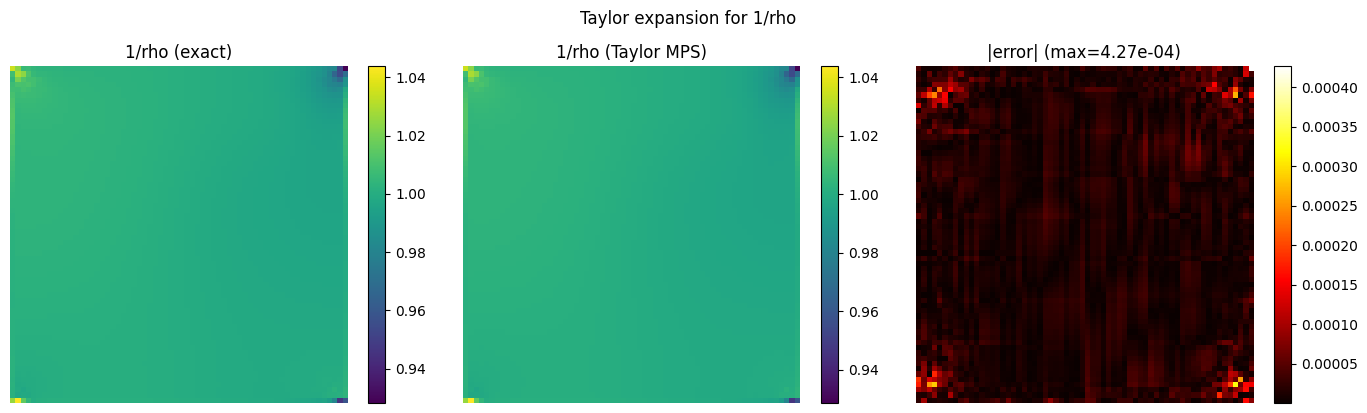

In [2]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])

# Run vanilla to get non-trivial density field
f = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
for _ in range(500):
    f = collide_bgk(D2Q9, f, tau)
    f = stream(D2Q9, f)
    f = apply_bounce_back(D2Q9, f, walls)
    f = apply_bounce_back_moving_top(D2Q9, f, u_wall)

rho_dense, u_dense = compute_moments(D2Q9, f)
inv_rho_exact = 1.0 / rho_dense

# MPS Taylor approximation
mps_list, meta = compress_populations(f, mapping='snake')
rho_mps, _, _ = compute_moments_mps(mps_list, D2Q9, max_bond=64)
ones_mps = build_ones_mps(len(mps_list[0].tensors))
inv_rho_mps = compute_inverse_density_mps(rho_mps, ones_mps, n, max_bond=64)
inv_rho_approx = qtt_to_field(inv_rho_mps, meta)

# Compare
taylor_err = np.max(np.abs(inv_rho_exact - inv_rho_approx))
rho_0 = rho_dense.mean()
delta_rho_max = np.max(np.abs(rho_dense - rho_0))
Ma = u_lid  # Mach number ~ u_lid for LBM

print(f"Taylor expansion for 1/rho (after 500 LBM steps):")
print(f"  rho range: [{rho_dense.min():.6f}, {rho_dense.max():.6f}]")
print(f"  rho_0 (mean): {rho_0:.6f}")
print(f"  max|delta_rho/rho_0|: {delta_rho_max/rho_0:.2e}")
print(f"  Ma = {Ma}")
print(f"  1/rho max error: {taylor_err:.2e}")
print(f"  Expected O(Ma^6) ~ {Ma**6:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(inv_rho_exact.T, origin='lower', cmap='viridis')
axes[0].set_title('1/rho (exact)'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(inv_rho_approx.T, origin='lower', cmap='viridis')
axes[1].set_title('1/rho (Taylor MPS)'); plt.colorbar(im1, ax=axes[1])
diff = np.abs(inv_rho_exact - inv_rho_approx)
im2 = axes[2].imshow(diff.T, origin='lower', cmap='hot')
axes[2].set_title(f'|error| (max={taylor_err:.2e})'); plt.colorbar(im2, ax=axes[2])
for ax in axes: ax.axis('off')
plt.suptitle('Taylor expansion for 1/rho', y=1.02)
plt.tight_layout()
plt.show()

## 2. Single-Step Collision Validation

Compare MPS collision vs dense collision on the same field. Track error per population and bond dimension growth.

In [3]:
# Dense collision reference
f_dense_col = collide_bgk(D2Q9, f, tau)

# MPS collision at different max_bond values
print("Single-step collision: MPS vs dense")
print("=" * 65)

for max_bond in [16, 32, 64]:
    mps_list, meta = compress_populations(f, mapping='snake')
    mps_col = collide_bgk_mps(mps_list, D2Q9, tau, n, max_bond=max_bond)
    f_mps_col = decompress_populations(mps_col, meta)
    
    total_err = np.max(np.abs(f_dense_col - f_mps_col))
    max_chi = max(m.max_bond() for m in mps_col)
    
    print(f"\n  max_bond={max_bond}: total_err={total_err:.2e}, output_chi={max_chi}")
    for i in range(9):
        err = np.max(np.abs(f_dense_col[i] - f_mps_col[i]))
        chi = mps_col[i].max_bond()
        print(f"    Pop {i} ({velocity_names[i]:>6}): err={err:.2e}, chi={chi}")

Single-step collision: MPS vs dense

  max_bond=16: total_err=2.35e-04, output_chi=16
    Pop 0 (  Rest): err=2.35e-04, chi=13
    Pop 1 (  East): err=8.02e-05, chi=16
    Pop 2 ( North): err=7.18e-05, chi=16
    Pop 3 (  West): err=7.18e-05, chi=16
    Pop 4 ( South): err=7.32e-05, chi=16
    Pop 5 (    NE): err=2.97e-05, chi=16
    Pop 6 (    NW): err=2.79e-05, chi=16
    Pop 7 (    SW): err=1.74e-05, chi=16
    Pop 8 (    SE): err=2.44e-05, chi=16

  max_bond=32: total_err=2.34e-04, output_chi=19
    Pop 0 (  Rest): err=2.34e-04, chi=13
    Pop 1 (  East): err=8.29e-05, chi=16
    Pop 2 ( North): err=5.62e-05, chi=16
    Pop 3 (  West): err=7.28e-05, chi=16
    Pop 4 ( South): err=7.93e-05, chi=16
    Pop 5 (    NE): err=1.51e-05, chi=18
    Pop 6 (    NW): err=1.44e-05, chi=19
    Pop 7 (    SW): err=1.38e-05, chi=18
    Pop 8 (    SE): err=1.31e-05, chi=19

  max_bond=64: total_err=2.34e-04, output_chi=19
    Pop 0 (  Rest): err=2.34e-04, chi=13
    Pop 1 (  East): err=8.29e-05, c

## 3. Fully MPS-Native LBM Loop

The complete pipeline with NO dense operations in the loop:
```
MPS collision -> MPS stream+BC -> decompress (for monitoring only) -> repeat
```

Run vanilla to convergence first, then MPS-LBM for the same number of steps.

In [4]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])
mapping = 'snake'
max_bond_col = 64   # for collision Hadamard products
max_nt = 15000
conv_tol = 1e-5

# ============================================================
# Step 1: Vanilla to convergence
# ============================================================
print(f"Step 1: Vanilla LBM to convergence ({n}x{n}, Re={Re})...")
f_van = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
u_prev = np.zeros((2, n, n))
consec = 0
t_conv = max_nt

for t in range(max_nt):
    f_van = collide_bgk(D2Q9, f_van, tau)
    f_van = stream(D2Q9, f_van)
    f_van = apply_bounce_back(D2Q9, f_van, walls)
    f_van = apply_bounce_back_moving_top(D2Q9, f_van, u_wall)
    _, u_v = compute_moments(D2Q9, f_van)
    du = np.max(np.abs(u_v - u_prev)) / (np.max(np.abs(u_v)) + 1e-10)
    u_prev = u_v.copy()
    consec = consec + 1 if (t > 0 and du < conv_tol) else 0
    if consec >= 2:
        t_conv = t
        print(f"  Converged at t={t} (du={du:.2e})")
        break
    if t % 2000 == 0:
        print(f"  t={t}, du={du:.2e}")

# ============================================================
# Step 2: Fully MPS-native LBM for t_conv steps
# ============================================================
print(f"\nStep 2: Fully MPS-native LBM for {t_conv} steps (max_bond={max_bond_col})...")
bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)

# Initialize as MPS
f_init = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
mps_list, meta = compress_populations(f_init, mapping=mapping)

history = {'t': [], 'mass': [], 'du': [], 'mean_chi': []}
u_prev_mps = np.zeros((2, n, n))
consec_mps = 0
t_conv_mps = None
t_start = time.time()

for t in range(t_conv + 1):
    # MPS collision (no dense!)
    mps_list = collide_bgk_mps(mps_list, D2Q9, tau, n, max_bond=max_bond_col)
    
    # MPS stream + BC (no dense!)
    mps_list = apply_mps_boundary(mps_list, D2Q9, bc_data, max_bond=max_bond_col)
    
    # Monitoring: decompress to check convergence (not part of the algorithm)
    if t % 200 == 0 or t == t_conv:
        f_check = decompress_populations(mps_list, meta)
        rho_check, u_check = compute_moments(D2Q9, f_check)
        du_mps = np.max(np.abs(u_check - u_prev_mps)) / (np.max(np.abs(u_check)) + 1e-10)
        u_prev_mps = u_check.copy()
        mean_chi = np.mean([m.max_bond() for m in mps_list])
        
        history['t'].append(t)
        history['mass'].append(np.sum(rho_check))
        history['du'].append(du_mps)
        history['mean_chi'].append(mean_chi)
        
        if t_conv_mps is None and t > 0 and du_mps < conv_tol:
            t_conv_mps = t
            print(f"  MPS-LBM converged at t={t} (du={du_mps:.2e})")
    
    if t % 1000 == 0 and t > 0:
        print(f"  t={t}: du={history['du'][-1]:.2e}, chi={history['mean_chi'][-1]:.1f}, "
              f"mass={history['mass'][-1]:.2f}")

elapsed = time.time() - t_start
print(f"\nDone in {elapsed:.0f}s.")
print(f"  Vanilla converged at t={t_conv}")
print(f"  MPS-LBM {'converged at t=' + str(t_conv_mps) if t_conv_mps else 'did NOT converge (in same steps)'}")

Step 1: Vanilla LBM to convergence (64x64, Re=100)...
  t=0, du=1.00e+00
  t=2000, du=1.69e-04
  t=4000, du=3.36e-05
  t=6000, du=1.57e-05
  Converged at t=7036 (du=9.93e-06)

Step 2: Fully MPS-native LBM for 7036 steps (max_bond=64)...
  t=1000: du=4.82e-02, chi=13.2, mass=4096.00
  t=2000: du=1.46e-02, chi=13.4, mass=4096.00
  t=3000: du=7.59e-03, chi=13.3, mass=4096.00
  t=4000: du=3.03e-03, chi=13.8, mass=4096.00
  t=5000: du=1.38e-03, chi=13.4, mass=4096.00
  t=6000: du=8.90e-04, chi=13.6, mass=4096.00
  t=7000: du=2.06e-03, chi=13.4, mass=4096.00

Done in 4202s.
  Vanilla converged at t=7036
  MPS-LBM did NOT converge (in same steps)


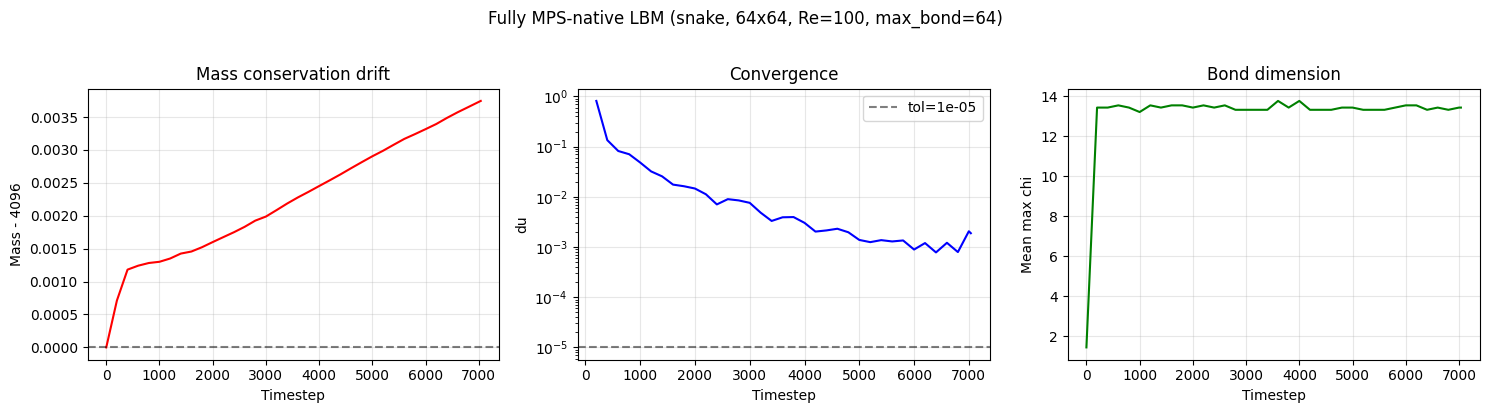

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

mass_drift = np.array(history['mass']) - n*n
axes[0].plot(history['t'], mass_drift, 'r-')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel(f'Mass - {n*n}')
axes[0].set_title('Mass conservation drift'); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(history['t'][1:], history['du'][1:], 'b-')
axes[1].axhline(conv_tol, color='k', linestyle='--', alpha=0.5, label=f'tol={conv_tol}')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('du')
axes[1].set_title('Convergence'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['t'], history['mean_chi'], 'g-')
axes[2].set_xlabel('Timestep'); axes[2].set_ylabel('Mean max chi')
axes[2].set_title('Bond dimension'); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Fully MPS-native LBM ({mapping}, {n}x{n}, Re={Re}, max_bond={max_bond_col})', y=1.02)
plt.tight_layout()
plt.show()

## 4. Ghia Benchmark

Compare the fully MPS-native LBM result against Ghia et al. and vanilla LBM.

RMS error vs Ghia (Re=100):
  Vanilla LBM:       0.045806
  Fully MPS-native:  0.022411


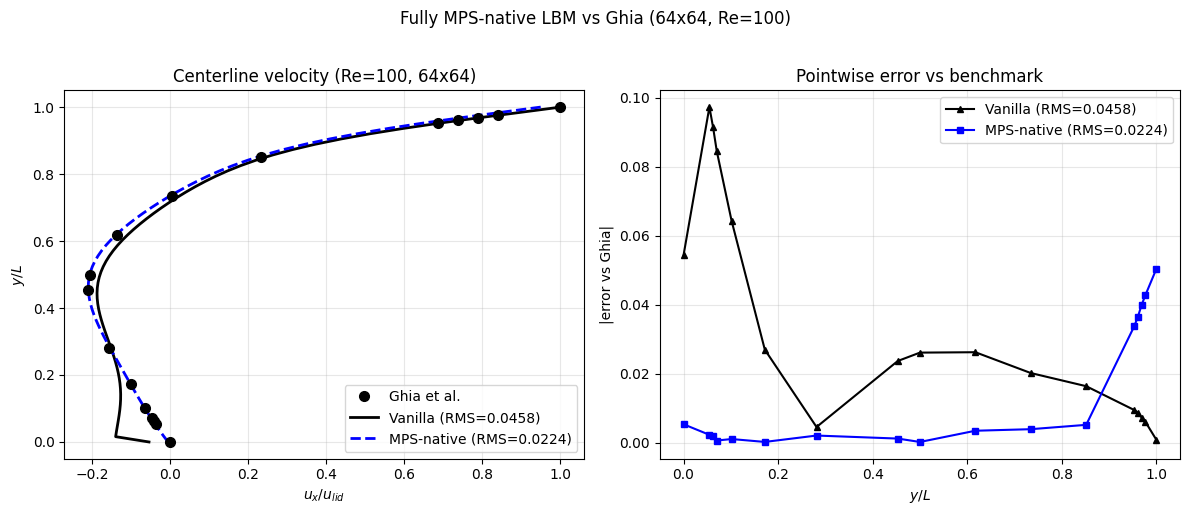

In [6]:
# Final velocity fields
f_mps_final = decompress_populations(mps_list, meta)
_, u_van = compute_moments(D2Q9, f_van)
_, u_mps = compute_moments(D2Q9, f_mps_final)

mid = n // 2
y_coords = np.linspace(0, 1, n)

ux_van = np.interp(GHIA_Y, y_coords, u_van[0, mid, :] / u_lid)
ux_mps = np.interp(GHIA_Y, y_coords, u_mps[0, mid, :] / u_lid)

rms_van = np.sqrt(np.mean((ux_van - GHIA_U_RE100)**2))
rms_mps = np.sqrt(np.mean((ux_mps - GHIA_U_RE100)**2))

print(f"RMS error vs Ghia (Re={Re}):")
print(f"  Vanilla LBM:       {rms_van:.6f}")
print(f"  Fully MPS-native:  {rms_mps:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=7, label='Ghia et al.', zorder=5)
ax.plot(u_van[0, mid, :]/u_lid, y_coords, 'k-', linewidth=2, label=f'Vanilla (RMS={rms_van:.4f})')
ax.plot(u_mps[0, mid, :]/u_lid, y_coords, 'b--', linewidth=2, label=f'MPS-native (RMS={rms_mps:.4f})')
ax.set_xlabel('$u_x / u_{lid}$'); ax.set_ylabel('$y / L$')
ax.set_title(f'Centerline velocity (Re={Re}, {n}x{n})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(GHIA_Y, np.abs(ux_van - GHIA_U_RE100), 'k^-', markersize=5, label=f'Vanilla (RMS={rms_van:.4f})')
ax.plot(GHIA_Y, np.abs(ux_mps - GHIA_U_RE100), 'bs-', markersize=5, label=f'MPS-native (RMS={rms_mps:.4f})')
ax.set_xlabel('$y / L$'); ax.set_ylabel('|error vs Ghia|')
ax.set_title('Pointwise error vs benchmark')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Fully MPS-native LBM vs Ghia ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

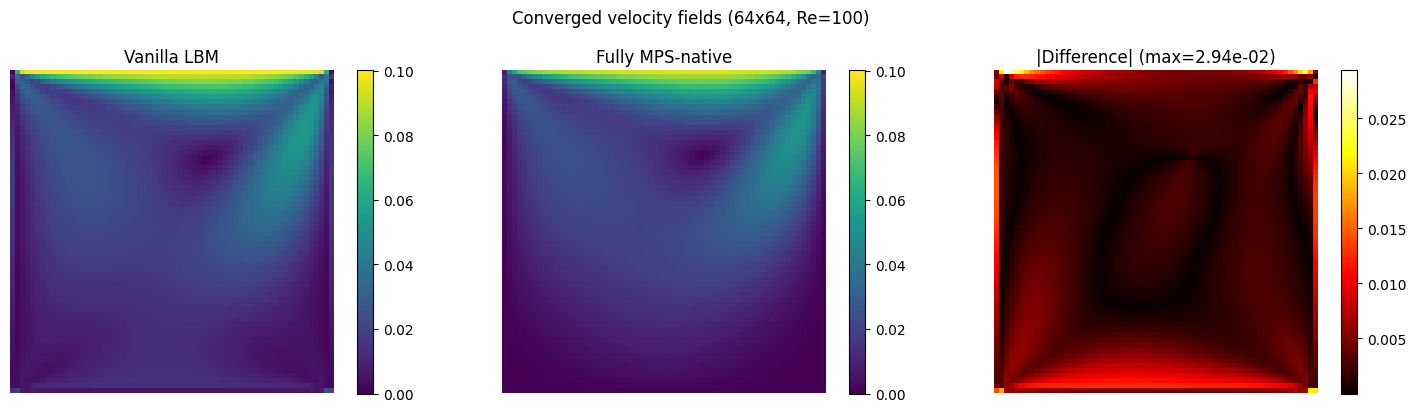

Final max velocity error vs vanilla: 3.33e-02
Final mass: 4096.00


In [7]:
speed_van = np.sqrt(u_van[0]**2 + u_van[1]**2)
speed_mps = np.sqrt(u_mps[0]**2 + u_mps[1]**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = max(speed_van.max(), speed_mps.max())

im0 = axes[0].imshow(speed_van.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[0].set_title('Vanilla LBM'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(speed_mps.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[1].set_title('Fully MPS-native'); plt.colorbar(im1, ax=axes[1])
diff = np.abs(speed_van - speed_mps)
im2 = axes[2].imshow(diff.T, origin='lower', cmap='hot')
axes[2].set_title(f'|Difference| (max={diff.max():.2e})'); plt.colorbar(im2, ax=axes[2])
for ax in axes: ax.axis('off')
plt.suptitle(f'Converged velocity fields ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Final max velocity error vs vanilla: {np.max(np.abs(u_van - u_mps)):.2e}")
print(f"Final mass: {np.sum(compute_moments(D2Q9, f_mps_final)[0]):.2f}")